# **Auto-settings**

## Data settings

In [1]:
# DIRCONF = r'F:\Sync\luhk_work\20 - CODING\22 - POET\configs'
# # DIRCONF = r'P:\Flux\RDS_calculations\_scripts\_configs\configs'  # Folder with configuration files: needed e.g. for connection to database
# TIMEZONE_OFFSET_TO_UTC_HOURS = 1  # Timezone, e.g. "1" is translated to timezone "UTC+01:00" (CET, winter time)
# REQUIRED_TIME_RESOLUTION = '30min'  # 30MIN time resolution

## Imports

In [2]:
import importlib.metadata
from datetime import datetime

import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np
import pandas as pd
import seaborn as sns
from pathlib import Path
from diive.core.io.files import save_parquet

sns.set_theme('notebook')
from diive.core.plotting.timeseries import TimeSeries
from diive.core.plotting.heatmap_datetime import HeatmapDateTime
from diive.core.times.times import TimestampSanitizer
from diive.pkgs.createvar.potentialradiation import potrad
from diive.pkgs.createvar.timesince import TimeSince
from diive.pkgs.gapfilling.xgboost_ts import XGBoostTS
from diive.core.io.files import load_parquet
import warnings

warnings.filterwarnings(action='ignore', category=FutureWarning)
warnings.filterwarnings(action='ignore', category=UserWarning)
dt_string = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
version_diive = importlib.metadata.version("diive")
print(f"diive version: v{version_diive}")

diive version: v0.89.0


In [3]:
# Project settings (dataset period, data paths): see src/config.py
import sys
from pathlib import Path
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "src" / "config.py").is_file())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
from src.config import DATA_DIR, PERIOD_START, PERIOD_END, select_period

</br>

# **LOAD DATA** from files

In [4]:
filename_meteo = DATA_DIR / "METEO" / "CH-TAN_meteo_gapfilled-meteoswiss_2023-24.csv"
meteo = pd.read_csv(filename_meteo)
meteo['TIMESTAMP_MIDDLE'] = pd.to_datetime(meteo['TIMESTAMP_END'], errors='coerce').dt.tz_localize(None) - pd.Timedelta(minutes=15)
meteo = meteo.set_index('TIMESTAMP_MIDDLE')
meteo.drop(columns='TIMESTAMP_END', inplace=True)
meteo

,g,pa,ppfd,prec,rh,swc_0.05,...,prec_is_meteoswiss,sw_in_is_meteoswiss,sw_out_is_meteoswiss,lw_in_is_meteoswiss,lw_out_is_meteoswiss,ppfd_is_meteoswiss
TIMESTAMP_MIDDLE,,,,,,,,,,,,,
2023-10-17 00:15:00,NaN,95.490000,0.822223,0.0,94.800000,NaN,...,1,1,1,1,1,1
2023-10-17 00:45:00,NaN,95.483333,0.120793,0.0,95.100000,NaN,...,1,1,1,1,1,1
2023-10-17 01:15:00,NaN,95.453333,-0.580637,0.0,94.966667,NaN,...,1,1,1,1,1,1
2023-10-17 01:45:00,NaN,95.430000,0.120793,0.0,94.366667,NaN,...,1,1,1,1,1,1
2023-10-17 02:15:00,NaN,95.426667,0.120793,0.0,95.600000,NaN,...,1,1,1,1,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-08-22 21:45:00,-26.544846,95.235333,0.000000,0.0,84.016666,14.569232,...,0,0,0,0,0,0
2024-08-22 22:15:00,-26.996622,95.232667,0.000000,0.0,87.603334,14.516813,...,0,0,0,0,0,0
2024-08-22 22:45:00,-26.066041,95.225333,0.000000,0.0,87.666666,14.474849,...,0,0,0,0,0,0


</br>

# **Select variables**

In [5]:
# cols_subset = ['TA', 'RH', 'PA', 'SW_IN', 'LW_IN', 'PPFD_IN', 'PREC', 'SWC_0.05', 'SWC_0.15', 'SWC_0.3', 'SWC_0.5', 'TS_0.05', 'TS_0.15', 'TS_0.3', 'TS_0.5']
# meteo = meteo[cols_subset]
# meteo

# Add timesince precipitation

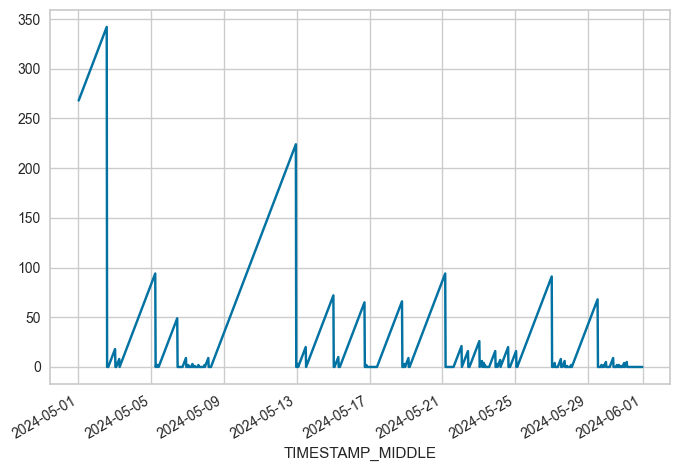

In [6]:
meteo = meteo.copy()
series_prec = meteo['prec'].copy()
ts_prec = TimeSince(series_prec, lower_lim=0, include_lim=False)
ts_prec.calc()
# ts_full_results = ts.get_full_results()
timesince = ts_prec.get_timesince()
meteo['timesince_prec'] = timesince
meteo.loc['2024-05', 'timesince_prec'].plot(x_compat=True);

# **Sanitize timestamp**

In [7]:
meteo = TimestampSanitizer(data=meteo).get()
meteo

,g,pa,ppfd,prec,rh,swc_0.05,...,sw_in_is_meteoswiss,sw_out_is_meteoswiss,lw_in_is_meteoswiss,lw_out_is_meteoswiss,ppfd_is_meteoswiss,timesince_prec
TIMESTAMP_MIDDLE,,,,,,,,,,,,,
2023-10-17 00:15:00,NaN,95.490000,0.822223,0.0,94.800000,NaN,...,1,1,1,1,1,1
2023-10-17 00:45:00,NaN,95.483333,0.120793,0.0,95.100000,NaN,...,1,1,1,1,1,2
2023-10-17 01:15:00,NaN,95.453333,-0.580637,0.0,94.966667,NaN,...,1,1,1,1,1,3
2023-10-17 01:45:00,NaN,95.430000,0.120793,0.0,94.366667,NaN,...,1,1,1,1,1,4
2023-10-17 02:15:00,NaN,95.426667,0.120793,0.0,95.600000,NaN,...,1,1,1,1,1,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-08-22 21:45:00,-26.544846,95.235333,0.000000,0.0,84.016666,14.569232,...,0,0,0,0,0,27
2024-08-22 22:15:00,-26.996622,95.232667,0.000000,0.0,87.603334,14.516813,...,0,0,0,0,0,28
2024-08-22 22:45:00,-26.066041,95.225333,0.000000,0.0,87.666666,14.474849,...,0,0,0,0,0,29


</br>

</br>

# **PLOT**

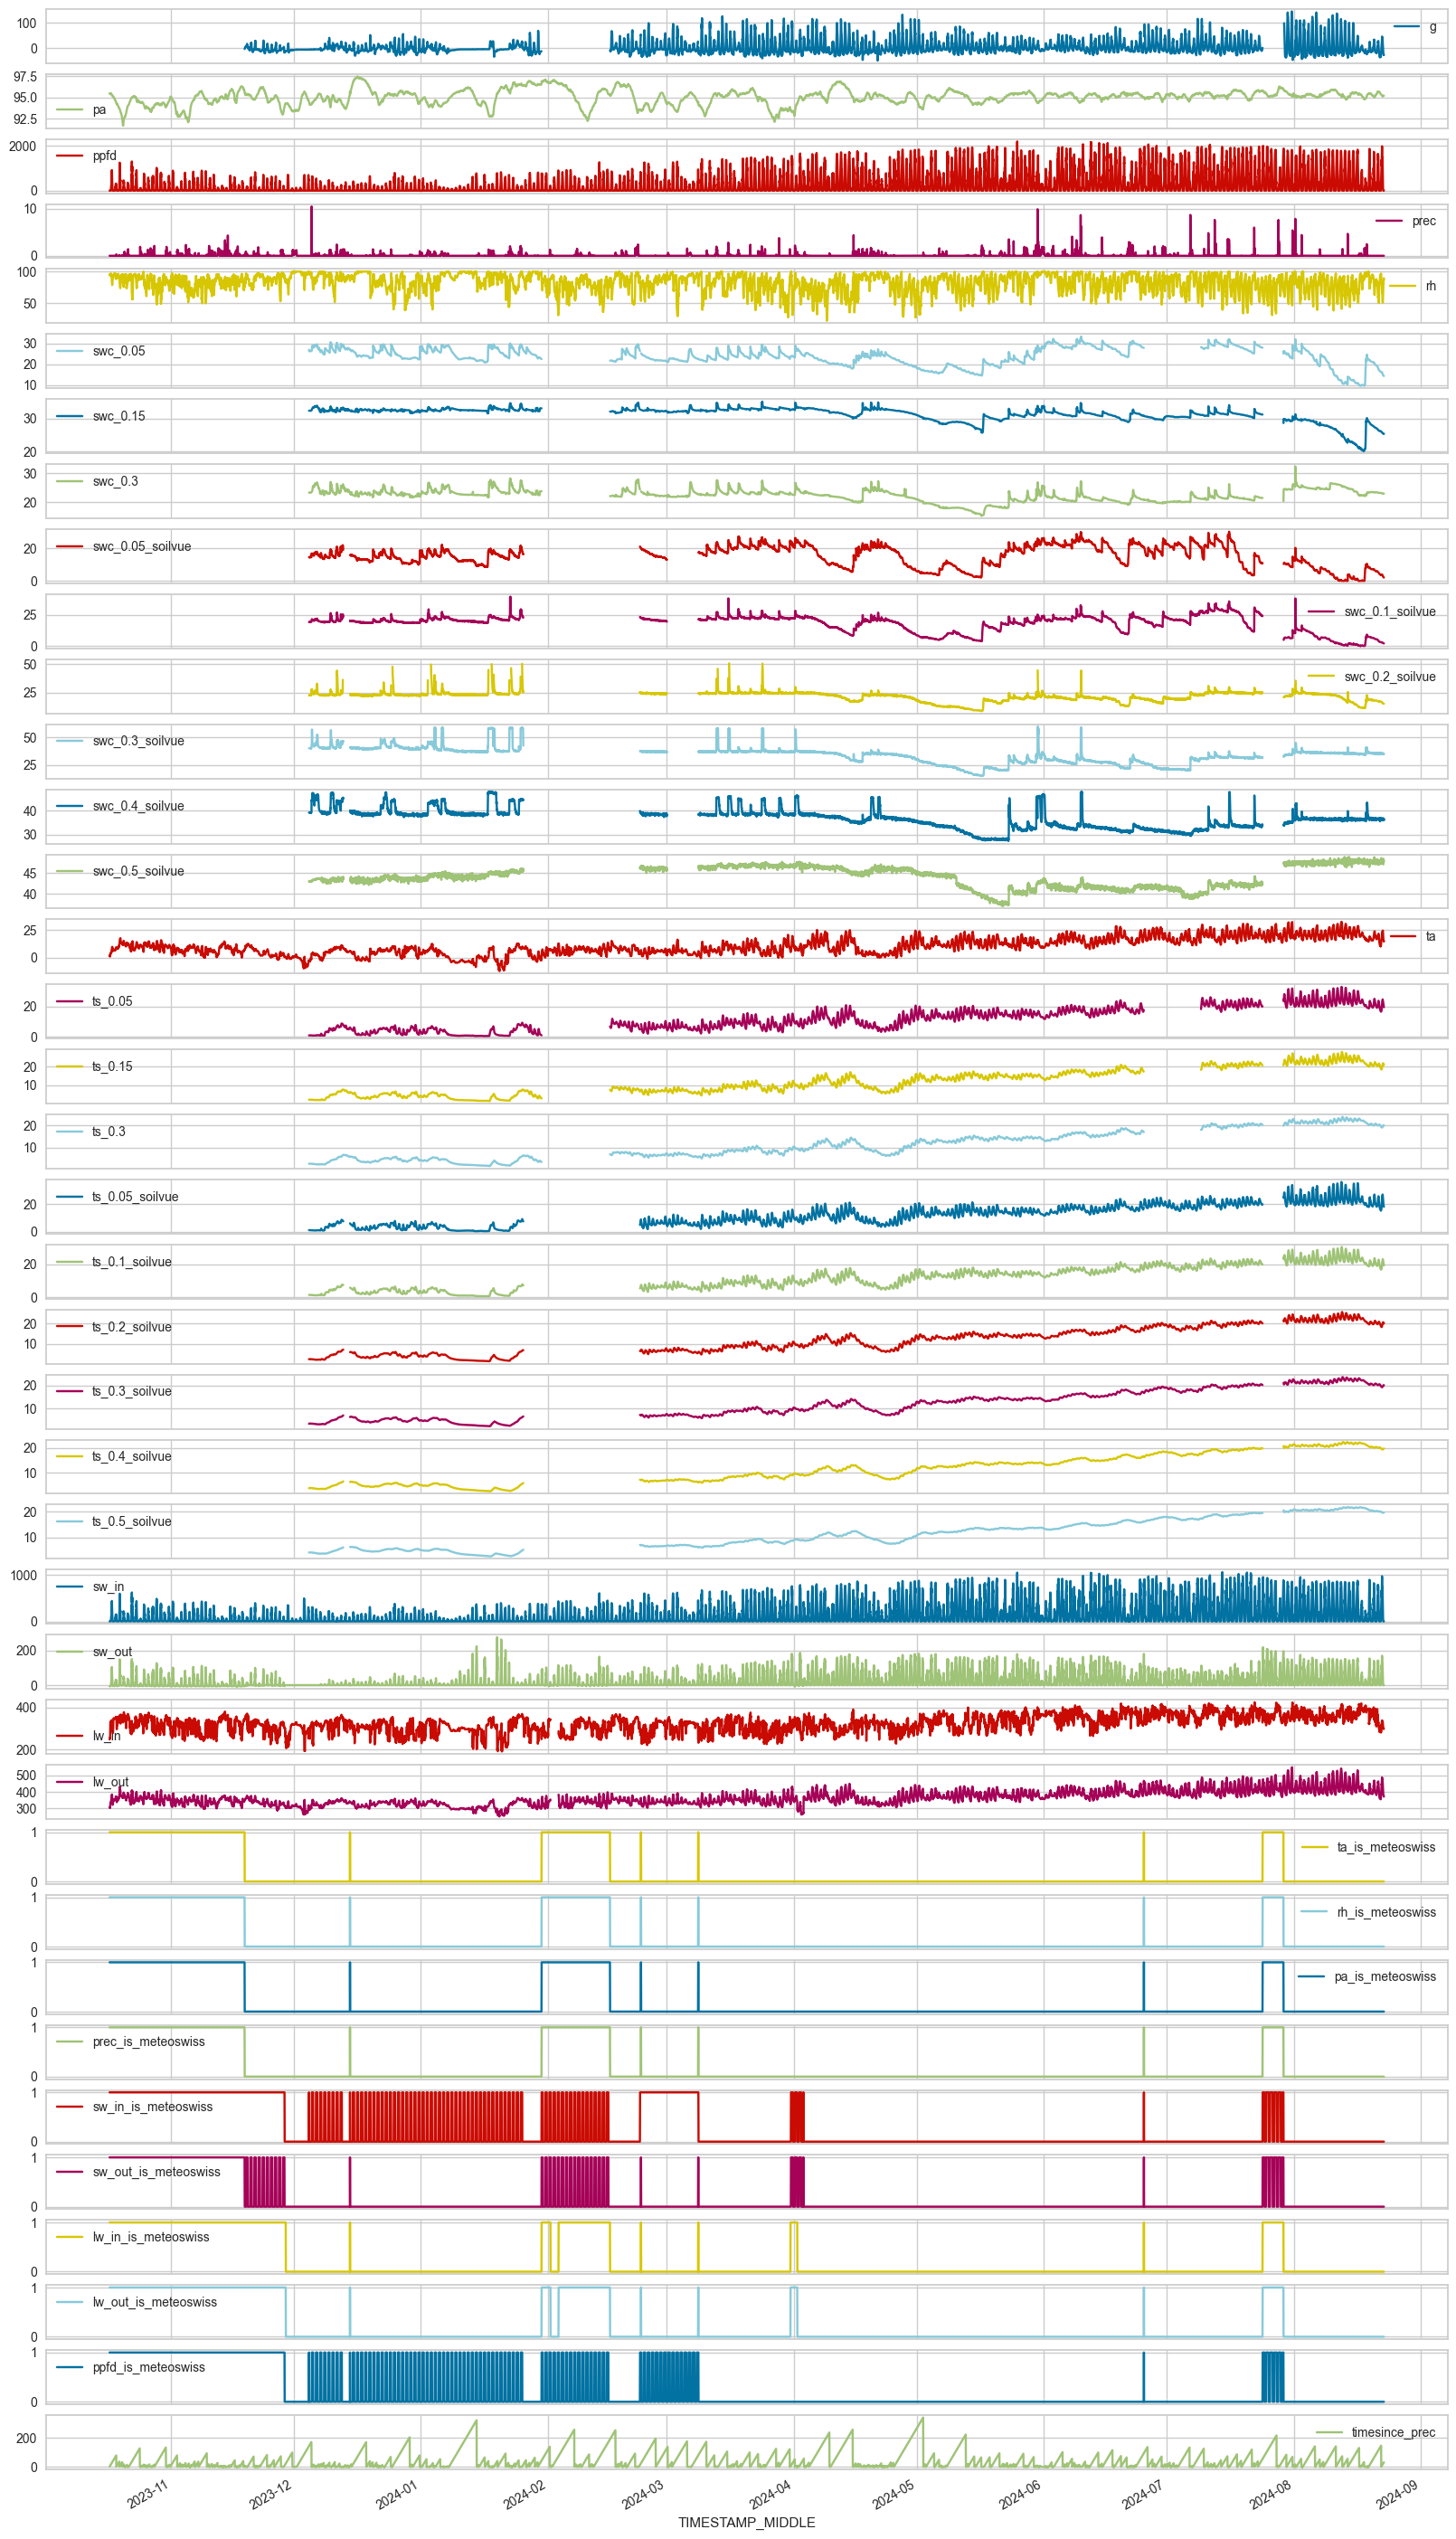

In [8]:
meteo.plot(subplots=True, x_compat=True, figsize=(20, 40));

</br>

# **Gap-filling**

## SW_IN

In [9]:
var = 'sw_in'

In [10]:
_df = pd.DataFrame()
_df[var] = meteo[var].copy()
_df['sw_in_pot'] = potrad(timestamp_index=_df.index,
                          lat=47.480620,  # CH-TAN
                          lon=8.911868,  # CH-TAN
                          utc_offset=1)
_df

,sw_in,sw_in_pot
TIMESTAMP_MIDDLE,,
2023-10-17 00:15:00,1.666667,0.0
2023-10-17 00:45:00,1.333333,0.0
2023-10-17 01:15:00,1.000000,0.0
2023-10-17 01:45:00,1.333333,0.0
2023-10-17 02:15:00,1.333333,0.0
...,...,...
2024-08-22 21:45:00,0.000000,0.0
2024-08-22 22:15:00,0.000000,0.0
2024-08-22 22:45:00,0.000000,0.0


### Set nighttime data to zero

In [11]:
# Detect nighttime
from diive.pkgs.createvar.daynightflag import DaytimeNighttimeFlag
dnf = DaytimeNighttimeFlag(
    timestamp_index=_df.index,
    nighttime_threshold=0.001,
    lat=47.480620,  # CH-TAN
    lon=8.911868,  # CH-TAN
    utc_offset=1)
nighttimeflag = dnf.get_nighttime_flag()
nighttime_ix = nighttimeflag == 1

Some nighttime data is above or below zero:

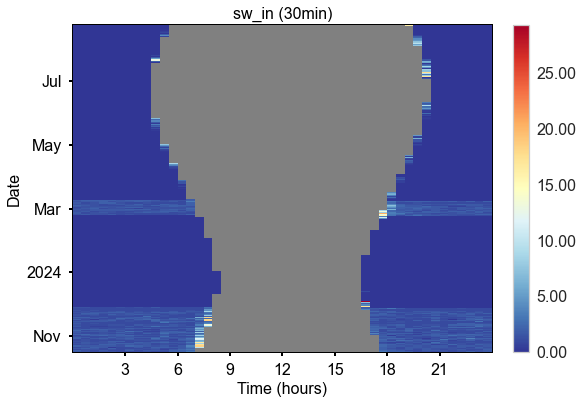

In [12]:
HeatmapDateTime(_df.loc[nighttime_ix, var]).plot()

In [13]:
_df.loc[nighttime_ix, var].describe()

count    7474.000000
mean        0.416117
std         1.208019
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max        29.331420
Name: sw_in, dtype: float64

In [14]:
_df.loc[nighttime_ix, var] = 0
_df.loc[nighttime_ix, var].describe()

count    7474.0
mean        0.0
std         0.0
min         0.0
25%         0.0
50%         0.0
75%         0.0
max         0.0
Name: sw_in, dtype: float64

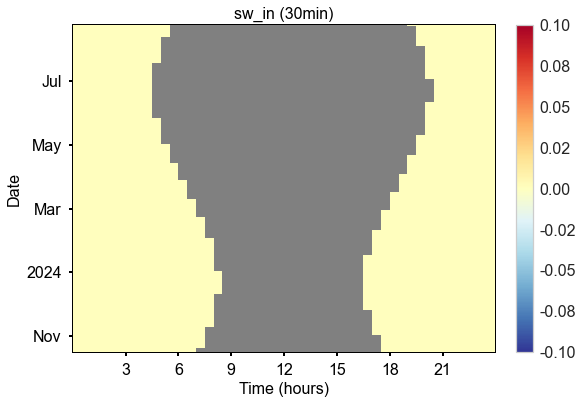

In [15]:
HeatmapDateTime(_df.loc[nighttime_ix, var]).plot()

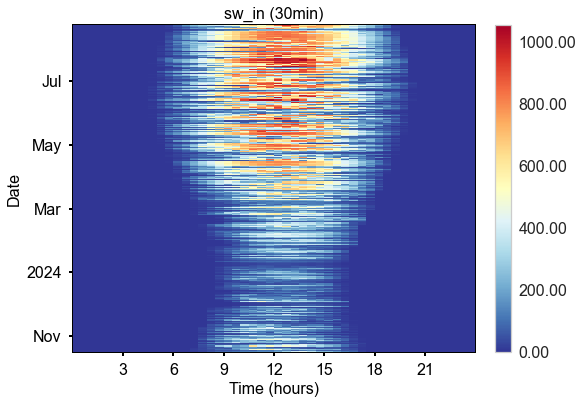

In [16]:
HeatmapDateTime(_df[var]).plot()

### Fill

In [17]:
if _df[var].isnull().any():
    xgb = XGBoostTS(
        input_df=_df,
        target_col=var,
        perm_n_repeats=10,
        include_timestamp_as_features=True,
        add_continuous_record_number=True,
        n_estimators=1000,
        random_state=42,
        early_stopping_rounds=50,
        n_jobs=-1
    )
else:
    print(f'No NAs in {var}, skipping gapfilling')

No NAs in sw_in, skipping gapfilling


In [18]:
# xgb.reduce_features()
# xgb.report_feature_reduction()

In [19]:
# xgb.trainmodel(showplot_scores=False, showplot_importance=False)
# xgb.report_traintest()

In [20]:
# xgb.fillgaps(showplot_scores=False, showplot_importance=False)
# xgb.report_gapfilling()

### Results

In [21]:
# results = xgb.gapfilling_df_
# results

### Add to data

In [22]:
# Combine data
if _df[var].isnull().any():
    meteo[var] = results[f'{var}_gfXG'].copy()
    meteo[var]
else:
    meteo[var] = _df[var].copy()
    meteo[var]

In [23]:
# Combine flags
if _df[var].isnull().any():
    meteo[f'FLAG_{var}_ISFILLED'] = results[f'FLAG_{var}_gfXG_ISFILLED'].copy()
    meteo[f'FLAG_{var}_ISFILLED']

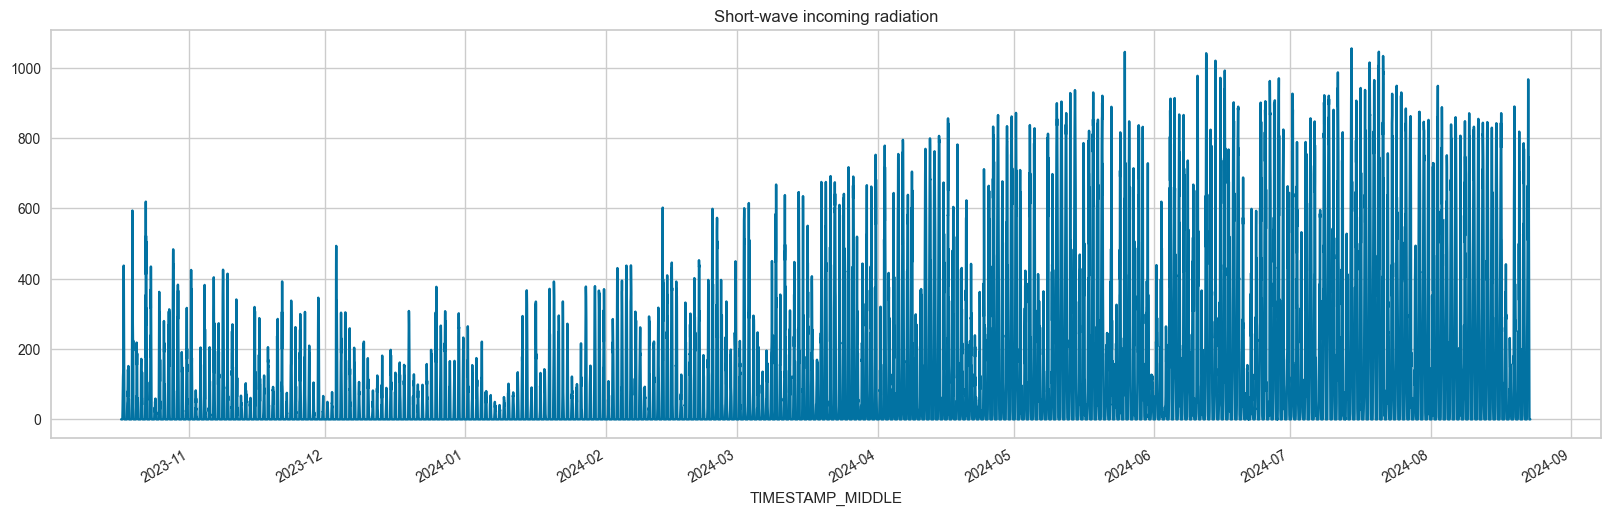

In [24]:
title = "Short-wave incoming radiation"
# meteo[['SW_IN', 'FLAG_SW_IN_ISFILLED']].plot(x_compat=True, title=title, subplots=True, figsize=(20, 6));

if _df[var].isnull().any():
    meteo[[var, f'FLAG_{var}_ISFILLED']].plot(x_compat=True, title=title, subplots=True, figsize=(20, 6));
else:
    meteo[var].plot(x_compat=True, title=title, figsize=(20, 6))

</br>

## TA

In [25]:
var = 'ta'

In [26]:
_df = pd.DataFrame()
_df['sw_in'] = meteo['sw_in'].copy()
_df[var] = meteo[var].copy()
_df

,sw_in,ta
TIMESTAMP_MIDDLE,,
2023-10-17 00:15:00,0.0,1.966667
2023-10-17 00:45:00,0.0,1.966667
2023-10-17 01:15:00,0.0,1.566667
2023-10-17 01:45:00,0.0,1.266667
2023-10-17 02:15:00,0.0,1.400000
...,...,...
2024-08-22 21:45:00,0.0,15.870000
2024-08-22 22:15:00,0.0,15.160000
2024-08-22 22:45:00,0.0,15.100000


### Fill

In [27]:
if _df[var].isnull().any():
    xgb = XGBoostTS(
        input_df=_df,
        target_col=var,
        perm_n_repeats=10,
        include_timestamp_as_features=True,
        add_continuous_record_number=True,
        n_estimators=1000,
        random_state=42,
        early_stopping_rounds=50,
        n_jobs=-1
    )
else:
    print(f'No NAs in {var}, skipping gapfilling')

No NAs in ta, skipping gapfilling


In [28]:
# xgb.reduce_features()
# xgb.report_feature_reduction()

In [29]:
# xgb.trainmodel(showplot_scores=False, showplot_importance=False)
# xgb.report_traintest()

In [30]:
# xgb.fillgaps(showplot_scores=False, showplot_importance=False)
# xgb.report_gapfilling()

### Results

In [31]:
# results = xgb.gapfilling_df_
# results

### Add to data

In [32]:
# Combine data
if _df[var].isnull().any():
    meteo[var] = results[f'{var}_gfXG'].copy()
    meteo[var]
else:
    meteo[var] = _df[var].copy()
    meteo[var]

In [33]:
# Combine flags
if _df[var].isnull().any():
    meteo[f'FLAG_{var}_ISFILLED'] = results[f'FLAG_{var}_gfXG_ISFILLED'].copy()
    meteo[f'FLAG_{var}_ISFILLED']

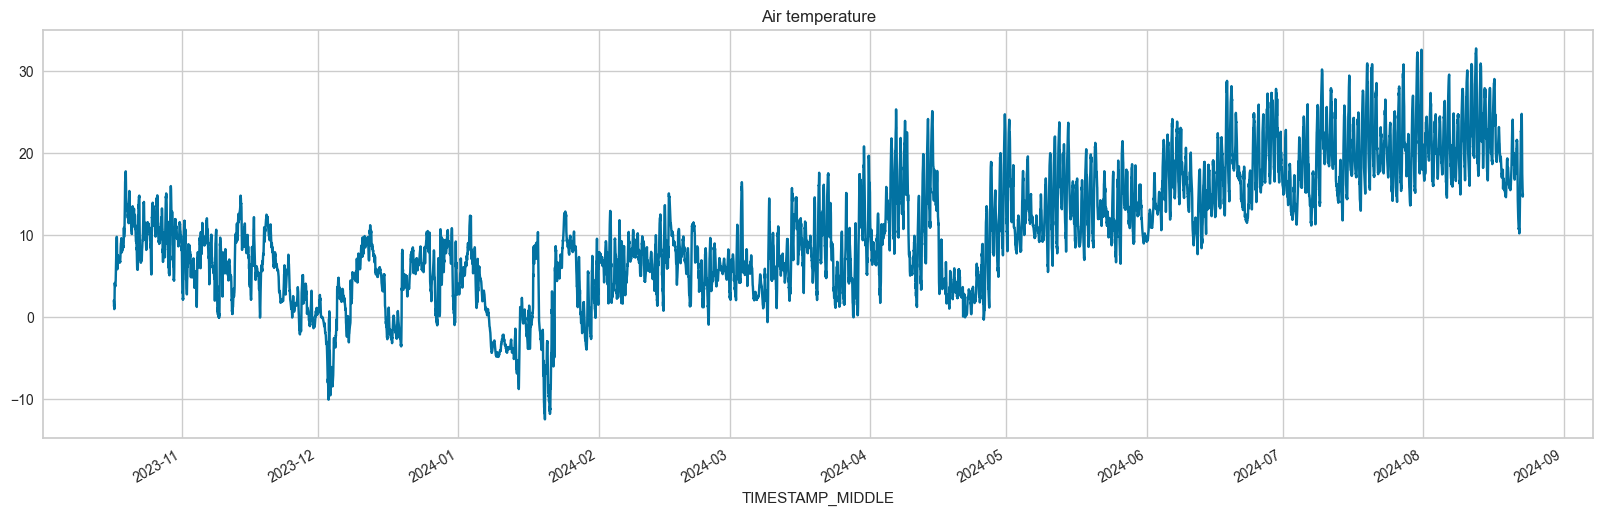

In [34]:
title = "Air temperature"
# meteo[['SW_IN', 'FLAG_SW_IN_ISFILLED']].plot(x_compat=True, title=title, subplots=True, figsize=(20, 6));

if _df[var].isnull().any():
    meteo[[var, f'FLAG_{var}_ISFILLED']].plot(x_compat=True, title=title, subplots=True, figsize=(20, 6));
else:
    meteo[var].plot(x_compat=True, title=title, figsize=(20, 6))

## PPFD

In [35]:
var = 'ppfd'

In [36]:
_df = pd.DataFrame()
_df[var] = meteo[[var]].copy()
_df['sw_in'] = meteo[['sw_in']].copy()
_df

,ppfd,sw_in
TIMESTAMP_MIDDLE,,
2023-10-17 00:15:00,0.822223,0.0
2023-10-17 00:45:00,0.120793,0.0
2023-10-17 01:15:00,-0.580637,0.0
2023-10-17 01:45:00,0.120793,0.0
2023-10-17 02:15:00,0.120793,0.0
...,...,...
2024-08-22 21:45:00,0.000000,0.0
2024-08-22 22:15:00,0.000000,0.0
2024-08-22 22:45:00,0.000000,0.0


### Set nighttime data to zero

In [37]:
# Detect nighttime
from diive.pkgs.createvar.daynightflag import DaytimeNighttimeFlag
dnf = DaytimeNighttimeFlag(
    timestamp_index=_df.index,
    nighttime_threshold=0.001,
    lat=47.480620,  # CH-TAN
    lon=8.911868,  # CH-TAN
    utc_offset=1)
nighttimeflag = dnf.get_nighttime_flag()
nighttime_ix = nighttimeflag == 1

Some nighttime data is above or below zero:

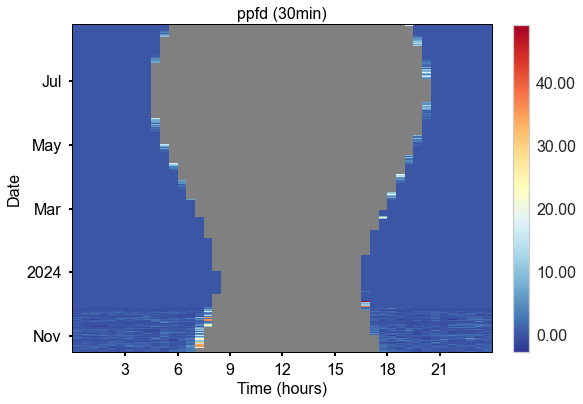

In [38]:
HeatmapDateTime(_df.loc[nighttime_ix, var]).plot()

In [39]:
_df.loc[nighttime_ix, var].describe()

count    7474.000000
mean        0.236642
std         1.787961
min        -2.684928
25%         0.000000
50%         0.000000
75%         0.000000
max        49.115962
Name: ppfd, dtype: float64

In [40]:
_df.loc[nighttime_ix, var] = 0
_df.loc[nighttime_ix, var].describe()

count    7474.0
mean        0.0
std         0.0
min         0.0
25%         0.0
50%         0.0
75%         0.0
max         0.0
Name: ppfd, dtype: float64

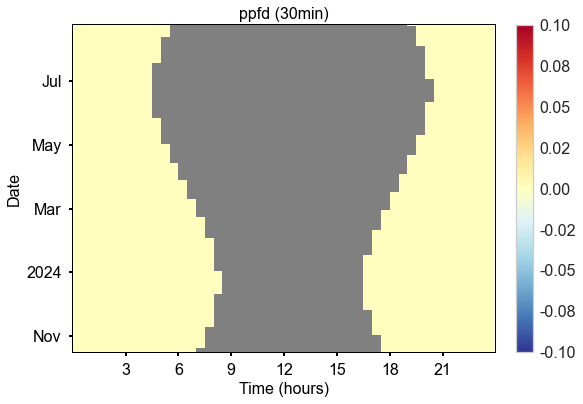

In [41]:
HeatmapDateTime(_df.loc[nighttime_ix, var]).plot()

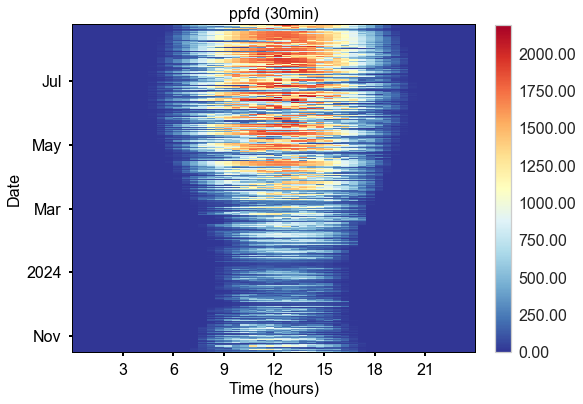

In [42]:
HeatmapDateTime(_df[var]).plot()

### Fill

In [43]:
if _df[var].isnull().any():
    xgb = XGBoostTS(
        input_df=_df,
        target_col=var,
        perm_n_repeats=10,
        include_timestamp_as_features=True,
        add_continuous_record_number=True,
        n_estimators=1000,
        random_state=42,
        early_stopping_rounds=50,
        n_jobs=-1
    )
else:
    print(f'No NAs in {var}, skipping gapfilling')

No NAs in ppfd, skipping gapfilling


In [44]:
# xgb.reduce_features()
# xgb.report_feature_reduction()

In [45]:
# xgb.trainmodel(showplot_scores=False, showplot_importance=False)
# xgb.report_traintest()

In [46]:
# xgb.fillgaps(showplot_scores=False, showplot_importance=False)
# xgb.report_gapfilling()

### Results

In [47]:
# results = xgb.gapfilling_df_
# results

### Add to data

In [48]:
# Combine data
if _df[var].isnull().any():
    meteo[var] = results[f'{var}_gfXG'].copy()
    meteo[var]
else:
    meteo[var] = _df[var].copy()
    meteo[var]

In [49]:
# Combine flags
if _df[var].isnull().any():
    meteo[f'FLAG_{var}_ISFILLED'] = results[f'FLAG_{var}_gfXG_ISFILLED'].copy()
    meteo[f'FLAG_{var}_ISFILLED']

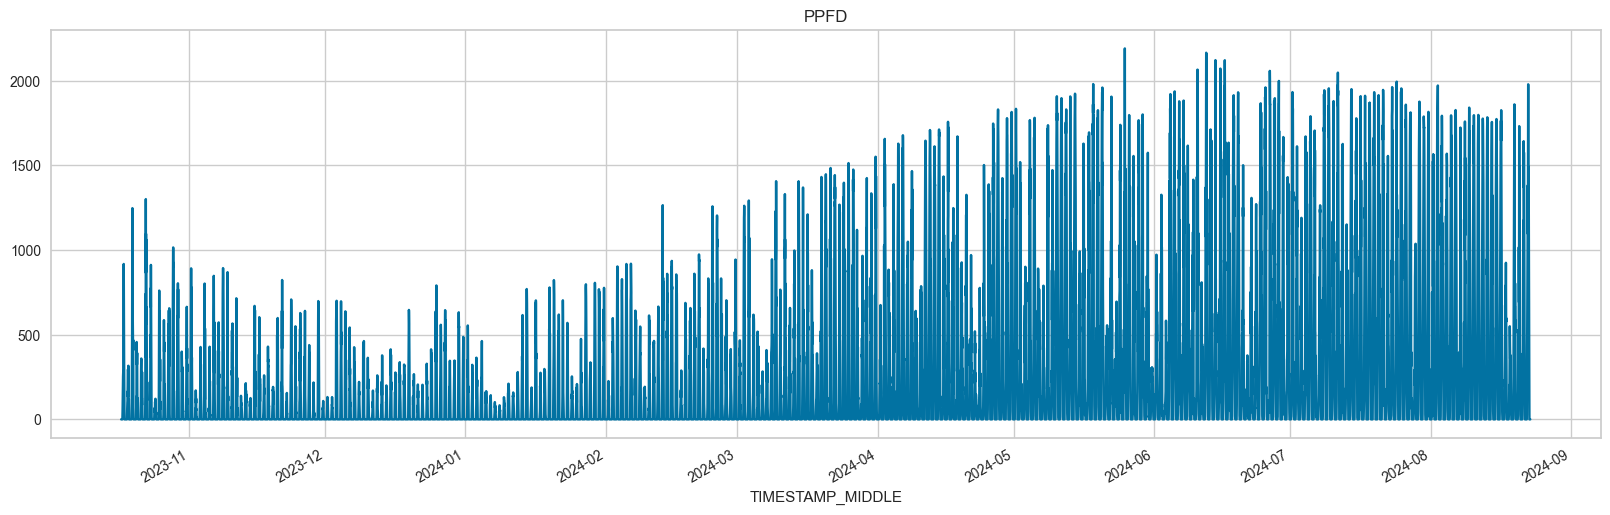

In [50]:
title = "PPFD"
# meteo[['SW_IN', 'FLAG_SW_IN_ISFILLED']].plot(x_compat=True, title=title, subplots=True, figsize=(20, 6));

if _df[var].isnull().any():
    meteo[[var, f'FLAG_{var}_ISFILLED']].plot(x_compat=True, title=title, subplots=True, figsize=(20, 6));
else:
    meteo[var].plot(x_compat=True, title=title, figsize=(20, 6))

## Calculate VPD (kPa)

In [51]:
from diive.pkgs.createvar.vpd import calc_vpd_from_ta_rh

In [52]:
var = 'vpd'

In [53]:
vpd = calc_vpd_from_ta_rh(df=meteo, rh_col='rh', ta_col='ta')
vpd

TIMESTAMP_MIDDLE
2023-10-17 00:15:00    0.036616
2023-10-17 00:45:00    0.034503
2023-10-17 01:15:00    0.034438
2023-10-17 01:45:00    0.037719
2023-10-17 02:15:00    0.029746
                         ...   
2024-08-22 21:45:00    0.288649
2024-08-22 22:15:00    0.213907
2024-08-22 22:45:00    0.211994
2024-08-22 23:15:00    0.176924
2024-08-22 23:45:00    0.210485
Freq: 30min, Name: VPD, Length: 14928, dtype: float64

In [54]:
meteo[var] = vpd

In [55]:
_df = pd.DataFrame()
_df[var] = meteo[var].copy()
_df['sw_in'] = meteo['sw_in'].copy()
_df['ta'] = meteo['ta'].copy()
_df

,vpd,sw_in,ta
TIMESTAMP_MIDDLE,,,
2023-10-17 00:15:00,0.036616,0.0,1.966667
2023-10-17 00:45:00,0.034503,0.0,1.966667
2023-10-17 01:15:00,0.034438,0.0,1.566667
2023-10-17 01:45:00,0.037719,0.0,1.266667
2023-10-17 02:15:00,0.029746,0.0,1.400000
...,...,...,...
2024-08-22 21:45:00,0.288649,0.0,15.870000
2024-08-22 22:15:00,0.213907,0.0,15.160000
2024-08-22 22:45:00,0.211994,0.0,15.100000


### Fill

In [56]:
if _df[var].isnull().any():
    xgb = XGBoostTS(
        input_df=_df,
        target_col=var,
        perm_n_repeats=10,
        include_timestamp_as_features=True,
        add_continuous_record_number=True,
        n_estimators=1000,
        random_state=42,
        early_stopping_rounds=50,
        n_jobs=-1
    )
else:
    print(f'No NAs in {var}, skipping gapfilling')

No NAs in vpd, skipping gapfilling


In [57]:
# xgb.reduce_features()
# xgb.report_feature_reduction()

In [58]:
# xgb.trainmodel(showplot_scores=False, showplot_importance=False)
# xgb.report_traintest()

In [59]:
# xgb.fillgaps(showplot_scores=False, showplot_importance=False)
# xgb.report_gapfilling()

### Results

In [60]:
# results = xgb.gapfilling_df_
# results

### Add to data

In [61]:
# Combine data
if _df[var].isnull().any():
    meteo[var] = results[f'{var}_gfXG'].copy()
    meteo[var]
else:
    meteo[var] = _df[var].copy()
    meteo[var]

In [62]:
# Combine flags
if _df[var].isnull().any():
    meteo[f'FLAG_{var}_ISFILLED'] = results[f'FLAG_{var}_gfXG_ISFILLED'].copy()
    meteo[f'FLAG_{var}_ISFILLED']

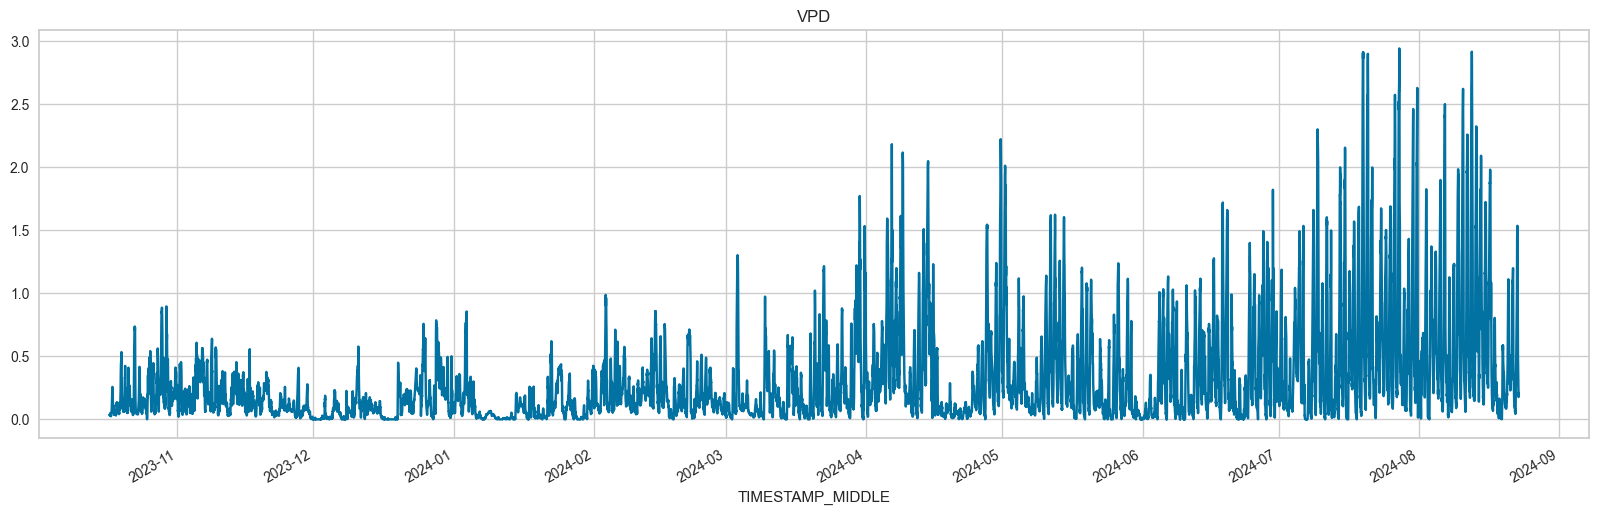

In [63]:
title = "VPD"
# meteo[['SW_IN', 'FLAG_SW_IN_ISFILLED']].plot(x_compat=True, title=title, subplots=True, figsize=(20, 6));

if _df[var].isnull().any():
    meteo[[var, f'FLAG_{var}_ISFILLED']].plot(x_compat=True, title=title, subplots=True, figsize=(20, 6));
else:
    meteo[var].plot(x_compat=True, title=title, figsize=(20, 6))

</br>

## TS

### TS_0.05

In [64]:
TARGET_COL = 'ts_0.05'
TARGET_GAPFILLED_COL = f'{TARGET_COL}_gfXG'
FLAG_GAPFILLED_COL = f'FLAG_{TARGET_GAPFILLED_COL}_ISFILLED'

# Dataframe for gap-filling
_df = pd.DataFrame()
_df[TARGET_COL] = meteo[TARGET_COL].copy()
_df['ta'] = meteo['ta']
_df['ta_roll_3h'] = meteo['ta'].rolling(window=6, min_periods=1).mean()

# XGBoost
xgb = XGBoostTS(
    input_df=_df,
    target_col=TARGET_COL,
    features_lag=[-10, -1],
    features_lag_exclude_cols=None,
    perm_n_repeats=10,
    include_timestamp_as_features=True,
    add_continuous_record_number=True,
    n_estimators=500,
    random_state=42,
    early_stopping_rounds=10,
    n_jobs=-1
)
xgb.trainmodel(showplot_scores=False, showplot_importance=False)
xgb.report_traintest()
xgb.fillgaps(showplot_scores=False, showplot_importance=False)
xgb.report_gapfilling()
results = xgb.gapfilling_df_

# Add results to main data
meteo[TARGET_GAPFILLED_COL] = results[TARGET_GAPFILLED_COL]
meteo[FLAG_GAPFILLED_COL] = results[FLAG_GAPFILLED_COL]

# Plot
plotdf = meteo[[TARGET_COL, TARGET_GAPFILLED_COL, 'ta', FLAG_GAPFILLED_COL]].copy()
plotdf.plot(x_compat=True, title=TARGET_COL, subplots=True, figsize=(20, 6));
plotdf['2024-06-15':'2024-07-17'].plot(x_compat=True, title=TARGET_COL, subplots=True, figsize=(20, 6));


Adding new data columns ...
++ Added new columns with timestamp info: ['.YEAR', '.SEASON', '.MONTH', '.WEEK', '.DOY', '.HOUR', '.YEARMONTH', '.YEARDOY', '.YEARWEEK'] 
++ Added new column .RECORDNUMBER with record numbers from 1 to 14928.

Training final model ...
>>> Training model <class 'xgboost.sklearn.XGBRegressor'> based on data between 2023-12-04 16:45:00 and 2024-08-22 23:45:00 ...
>>> Fitting model to training data ...
[0]	validation_0-rmse:5.17918	validation_1-rmse:5.15379
[1]	validation_0-rmse:3.68917	validation_1-rmse:3.66754
[2]	validation_0-rmse:2.64968	validation_1-rmse:2.63519
[3]	validation_0-rmse:1.92707	validation_1-rmse:1.92081
[4]	validation_0-rmse:1.43263	validation_1-rmse:1.43862
[5]	validation_0-rmse:1.09267	validation_1-rmse:1.11262
[6]	validation_0-rmse:0.86515	validation_1-rmse:0.89729
[7]	validation_0-rmse:0.71807	validation_1-rmse:0.76302
[8]	validation_0-rmse:0.62273	validation_1-rmse:0.68080
[9]	validation_0-rmse:0.55757	validation_1-rmse:0.62520
[10]	val

KeyboardInterrupt: 

### TS_0.15

In [ ]:
TARGET_COL = 'ts_0.15'
TARGET_GAPFILLED_COL = f'{TARGET_COL}_gfXG'
FLAG_GAPFILLED_COL = f'FLAG_{TARGET_GAPFILLED_COL}_ISFILLED'

# Dataframe for gap-filling
_df = pd.DataFrame()
_df[TARGET_COL] = meteo[TARGET_COL].copy()
_df['ta'] = meteo['ta']
_df['ta_roll_3h'] = meteo['ta'].rolling(window=6, min_periods=1).mean()
_df['ta_roll_6h'] = meteo['ta'].rolling(window=12, min_periods=1).mean()

# XGBoost
xgb = XGBoostTS(
    input_df=_df,
    target_col=TARGET_COL,
    features_lag=[-10, -1],
    features_lag_exclude_cols=None,
    perm_n_repeats=10,
    include_timestamp_as_features=True,
    add_continuous_record_number=True,
    n_estimators=500,
    random_state=42,
    early_stopping_rounds=10,
    n_jobs=-1
)
xgb.trainmodel(showplot_scores=False, showplot_importance=False)
xgb.report_traintest()
xgb.fillgaps(showplot_scores=False, showplot_importance=False)
xgb.report_gapfilling()
results = xgb.gapfilling_df_

# Add results to main data
meteo[TARGET_GAPFILLED_COL] = results[TARGET_GAPFILLED_COL]
meteo[FLAG_GAPFILLED_COL] = results[FLAG_GAPFILLED_COL]

# Plot
plotdf = meteo[[TARGET_COL, TARGET_GAPFILLED_COL, 'ta', FLAG_GAPFILLED_COL]].copy()
plotdf.plot(x_compat=True, title=TARGET_COL, subplots=True, figsize=(20, 6));
plotdf['2024-06-15':'2024-07-17'].plot(x_compat=True, title=TARGET_COL, subplots=True, figsize=(20, 6));

### TS_3

In [ ]:
TARGET_COL = 'ts_0.3'
TARGET_GAPFILLED_COL = f'{TARGET_COL}_gfXG'
FLAG_GAPFILLED_COL = f'FLAG_{TARGET_GAPFILLED_COL}_ISFILLED'

# Dataframe for gap-filling
_df = pd.DataFrame()
_df[TARGET_COL] = meteo[TARGET_COL].copy()
_df['ta'] = meteo['ta']
_df['ta_roll_3h'] = meteo['ta'].rolling(window=6, min_periods=1).mean()
_df['ta_roll_6h'] = meteo['ta'].rolling(window=12, min_periods=1).mean()
_df['ta_roll_12h'] = meteo['ta'].rolling(window=24, min_periods=1).mean()

# XGBoost
xgb = XGBoostTS(
    input_df=_df,
    target_col=TARGET_COL,
    features_lag=[-20, -1],
    features_lag_exclude_cols=None,
    perm_n_repeats=10,
    include_timestamp_as_features=True,
    add_continuous_record_number=True,
    n_estimators=500,
    random_state=42,
    early_stopping_rounds=10,
    n_jobs=-1
)
xgb.trainmodel(showplot_scores=False, showplot_importance=False)
xgb.report_traintest()
xgb.fillgaps(showplot_scores=False, showplot_importance=False)
xgb.report_gapfilling()
results = xgb.gapfilling_df_

# Add results to main data
meteo[TARGET_GAPFILLED_COL] = results[TARGET_GAPFILLED_COL]
meteo[FLAG_GAPFILLED_COL] = results[FLAG_GAPFILLED_COL]

# Plot
plotdf = meteo[[TARGET_COL, TARGET_GAPFILLED_COL, 'ta', FLAG_GAPFILLED_COL]].copy()
plotdf.plot(x_compat=True, title=TARGET_COL, subplots=True, figsize=(20, 6));
plotdf['2024-06-15':'2024-07-17'].plot(x_compat=True, title=TARGET_COL, subplots=True, figsize=(20, 6));

## SWC 5 TM

### SWC_0.05

In [ ]:
TARGET_COL = 'swc_0.05'
TARGET_GAPFILLED_COL = f'{TARGET_COL}_gfXG'
FLAG_GAPFILLED_COL = f'FLAG_{TARGET_GAPFILLED_COL}_ISFILLED'

# Dataframe for gap-filling
_df = pd.DataFrame()
_df[TARGET_COL] = meteo[TARGET_COL].copy()
_df['prec'] = meteo['prec'].copy()
_df['timesince_prec'] = meteo['timesince_prec'].copy()
_df['prec_roll_24h'] = meteo['prec'].rolling(window=48, min_periods=1).sum()
_df['ta_roll_3h'] = meteo['ta'].rolling(window=6, min_periods=1).mean()
_df['ta_roll_6h'] = meteo['ta'].rolling(window=12, min_periods=1).mean()

# XGBoost
xgb = XGBoostTS(
    input_df=_df,
    target_col=TARGET_COL,
    features_lag=[-10, -1],
    features_lag_exclude_cols=['timesince_prec'],
    perm_n_repeats=10,
    include_timestamp_as_features=True,
    add_continuous_record_number=True,
    n_estimators=500,
    random_state=42,
    early_stopping_rounds=10,
    n_jobs=-1
)
xgb.reduce_features()
xgb.report_feature_reduction()
xgb.trainmodel(showplot_scores=False, showplot_importance=False)
xgb.report_traintest()
xgb.fillgaps(showplot_scores=False, showplot_importance=False)
xgb.report_gapfilling()
results = xgb.gapfilling_df_

# Add results to main data
meteo[TARGET_GAPFILLED_COL] = results[TARGET_GAPFILLED_COL]
meteo[FLAG_GAPFILLED_COL] = results[FLAG_GAPFILLED_COL]

# Plot
plotdf = meteo[[TARGET_COL, TARGET_GAPFILLED_COL, FLAG_GAPFILLED_COL]].copy()
plotdf.plot(x_compat=True, title=TARGET_COL, subplots=True, figsize=(20, 6));
plotdf['2024-06-15':'2024-07-17'].plot(x_compat=True, title=TARGET_COL, subplots=True, figsize=(20, 6));

### SWC_0.15

In [ ]:
TARGET_COL = 'swc_0.15'
TARGET_GAPFILLED_COL = f'{TARGET_COL}_gfXG'
FLAG_GAPFILLED_COL = f'FLAG_{TARGET_GAPFILLED_COL}_ISFILLED'

# Dataframe for gap-filling
_df = pd.DataFrame()
_df[TARGET_COL] = meteo[TARGET_COL].copy()
_df['prec'] = meteo['prec'].copy()
_df['timesince_prec'] = meteo['timesince_prec'].copy()
_df['prec_roll_24h'] = meteo['prec'].rolling(window=48, min_periods=1).sum()
_df['ta_roll_3h'] = meteo['ta'].rolling(window=6, min_periods=1).mean()
_df['ta_roll_6h'] = meteo['ta'].rolling(window=12, min_periods=1).mean()

# XGBoost
xgb = XGBoostTS(
    input_df=_df,
    target_col=TARGET_COL,
    features_lag=[-10, -1],
    features_lag_exclude_cols=['timesince_prec'],
    perm_n_repeats=10,
    include_timestamp_as_features=True,
    add_continuous_record_number=True,
    n_estimators=500,
    random_state=42,
    early_stopping_rounds=10,
    n_jobs=-1
)
xgb.reduce_features()
xgb.report_feature_reduction()
xgb.trainmodel(showplot_scores=False, showplot_importance=False)
xgb.report_traintest()
xgb.fillgaps(showplot_scores=False, showplot_importance=False)
xgb.report_gapfilling()
results = xgb.gapfilling_df_

# Add results to main data
meteo[TARGET_GAPFILLED_COL] = results[TARGET_GAPFILLED_COL]
meteo[FLAG_GAPFILLED_COL] = results[FLAG_GAPFILLED_COL]

# Plot
plotdf = meteo[[TARGET_COL, TARGET_GAPFILLED_COL, FLAG_GAPFILLED_COL]].copy()
plotdf.plot(x_compat=True, title=TARGET_COL, subplots=True, figsize=(20, 6));
plotdf['2024-07-15':'2024-08-15'].plot(x_compat=True, title=TARGET_COL, subplots=True, figsize=(20, 6));

### SWC_0.3

In [ ]:
TARGET_COL = 'swc_0.3'
TARGET_GAPFILLED_COL = f'{TARGET_COL}_gfXG'
FLAG_GAPFILLED_COL = f'FLAG_{TARGET_GAPFILLED_COL}_ISFILLED'

# Dataframe for gap-filling
_df = pd.DataFrame()
_df[TARGET_COL] = meteo[TARGET_COL].copy()
_df['prec'] = meteo['prec'].copy()
_df['timesince_prec'] = meteo['timesince_prec'].copy()
_df['prec_roll_24h'] = meteo['prec'].rolling(window=48, min_periods=1).sum()
_df['ta_roll_3h'] = meteo['ta'].rolling(window=6, min_periods=1).mean()
_df['ta_roll_6h'] = meteo['ta'].rolling(window=12, min_periods=1).mean()

# XGBoost
xgb = XGBoostTS(
    input_df=_df,
    target_col=TARGET_COL,
    features_lag=[-10, -1],
    features_lag_exclude_cols=['timesince_prec'],
    perm_n_repeats=10,
    include_timestamp_as_features=True,
    add_continuous_record_number=True,
    n_estimators=500,
    random_state=42,
    early_stopping_rounds=10,
    n_jobs=-1
)
xgb.reduce_features()
xgb.report_feature_reduction()
xgb.trainmodel(showplot_scores=False, showplot_importance=False)
xgb.report_traintest()
xgb.fillgaps(showplot_scores=False, showplot_importance=False)
xgb.report_gapfilling()
results = xgb.gapfilling_df_

# Add results to main data
meteo[TARGET_GAPFILLED_COL] = results[TARGET_GAPFILLED_COL]
meteo[FLAG_GAPFILLED_COL] = results[FLAG_GAPFILLED_COL]

# Plot
plotdf = meteo[[TARGET_COL, TARGET_GAPFILLED_COL, FLAG_GAPFILLED_COL]].copy()
plotdf.plot(x_compat=True, title=TARGET_COL, subplots=True, figsize=(20, 6));
plotdf['2024-07-15':'2024-08-15'].plot(x_compat=True, title=TARGET_COL, subplots=True, figsize=(20, 6));

# **Plots**

In [ ]:
_plot_df = meteo.copy()
_plot_df = _plot_df.replace(-9999, np.nan)

## Time series plot

In [ ]:
_plot_df.plot(subplots=True, figsize=(50, 50), title="Gap-filled meteo data", alpha=.9, x_compat=True);

## Heatmaps

In [ ]:
for col in _plot_df.columns:
    series = _plot_df[col]
    series.name = col
    HeatmapDateTime(series, figsize=(6, 9)).show()

</br>

# **Stats**

In [ ]:
meteo.describe().T

</br>

In [ ]:
meteo

</br>

# **Save measured and gap-filled data to parquet**

In [ ]:
OUTNAME = "13.1_CH-TAN_meteo_gapfilled"
OUTPATH = ""
filepath = save_parquet(filename=OUTNAME, data=meteo, outpath=OUTPATH)

</br>

# **End of notebook**.

In [ ]:
dt_string = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
print(f"Finished. {dt_string}")